<a href="https://colab.research.google.com/github/MuhammadUsmanAslam111/ai_intern_week04/blob/main/CIFAR_10_implementation_of_CNN_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy  as np
from tensorflow import keras
import matplotlib as plt

In [2]:
data=keras.datasets.cifar10

In [3]:
(train_images,train_labels), (test_images,test_labels)=data.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [4]:
print(train_images.shape)
print(test_images.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


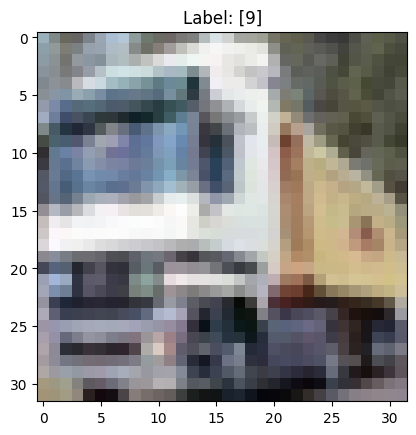

In [5]:
import matplotlib.pyplot as plt

plt.imshow(train_images[1], cmap='gray')
plt.title(f"Label: {train_labels[1]}")
plt.show()

In [6]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

In [7]:
for i, name in enumerate(class_names):
    print(i, "→", name)

0 → airplane
1 → automobile
2 → bird
3 → cat
4 → deer
5 → dog
6 → frog
7 → horse
8 → ship
9 → truck


In [8]:
train_images=train_images/255
test_images=test_images/255

In [9]:
model = keras.Sequential([
    keras.layers.Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),
   keras.layers.Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),
    keras.layers.Flatten(),
    keras.layers.Dense(
        64,
        activation='relu'
    ),
    keras.layers.Dense(10, activation='softmax')
  ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [11]:
model.fit(train_images,train_labels,epochs=7)

Epoch 1/7
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 117s 74ms/step - accuracy: 0.4328 - loss: 1.5817
Epoch 2/7
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 115s 74ms/step - accuracy: 0.6387 - loss: 1.0291
Epoch 3/7
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 140s 73ms/step - accuracy: 0.7251 - loss: 0.7931
Epoch 4/7
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 115s 73ms/step - accuracy: 0.7795 - loss: 0.6255
Epoch 5/7
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 118s 75ms/step - accuracy: 0.8414 - loss: 0.4604
Epoch 6/7
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 115s 74ms/step - accuracy: 0.8896 - loss: 0.3230
Epoch 7/7
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 141s 74ms/step - accuracy: 0.9304 - loss: 0.2080


In [12]:
test_loss , test_acc =model.evaluate(test_images,test_labels)
print("test ACC: ",test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.6259 - loss: 1.6233
test ACC:  0.6258000135421753


In [13]:
prediction=model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


/tmp/ipykernel_204/2383366510.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.xlabel("Actual: " + class_names[int(test_labels[i])])


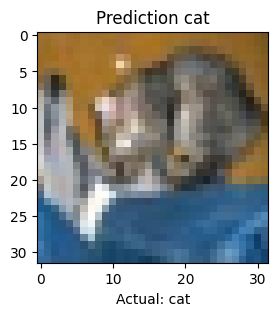

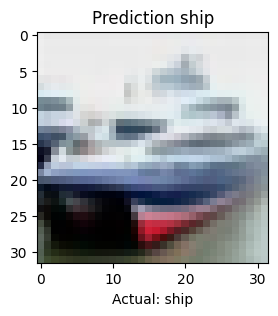

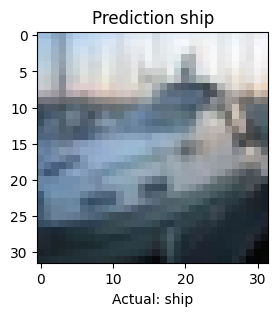

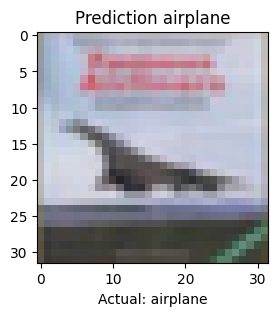

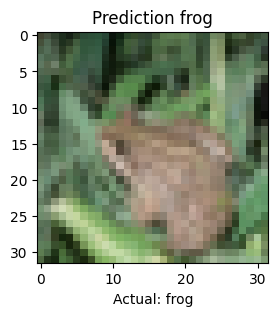

In [14]:
for i in range(5):
    plt.figure(figsize=(3, 3))  #
    plt.grid(False)
    plt.imshow(test_images[i], cmap=plt.cm.binary)
    plt.xlabel("Actual: " + class_names[int(test_labels[i])])
    plt.title("Prediction " + class_names[np.argmax(prediction[i])])
    plt.show()

In [15]:
model.save('best_model.h5')